### Alzheimer's Disease Diagnosis via XGBoost 
Problem Statement: Alzheimer's disease is a progressive neural disorder that affects memory, thinking, and behavior. Early diagnosis is difficult because the symptomes may appear gradually and can resemble normal aging. With delayed detection and treatment it can reduce the effectiveness in treatment and patient care. This project aims to develop a model capable of predicting the likelihood of Alzheimer's disease using a patient health and cognitive data to assist in earlier and more accurate diagnosis.

Target Variable: Diagnosis [ 0 = No Alzheimer's, 1 = Alzheimer's]

### Step 1: Import Libraries

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = ['#4C72B0', '#DD8452']
print("Libraries loaded.")


Libraries loaded.


### Step 2: Load Dataset & Preprocessing

In [ ]:
data = pd.read_csv('../datasets/alzheimers_disease_data.csv')

drop_cols = ['PatientID', 'DoctorInCharge']
data.drop(columns=drop_cols, inplace=True)

print("Data loaded and preprocessed. \nShape:", data.shape[0], "rows and", data.shape[1], "columns.")

Data loaded and preprocessed. 
Shape: 2149 rows and 33 columns.


In [14]:
data.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,6.045039,0,0,0.014691,0,0,1,1,0,0


### Step 3: Exploratory Data Analysis

In [32]:
print("Data Info & Summary:")
data.info()
print()
print("\nMissing Values:\n", data.isnull().sum())
print()
print("\nStatistical Summary:")
data.describe()

Data Info & Summary:
<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        2149 non-null   int64  
 1   Gender                     2149 non-null   int64  
 2   Ethnicity                  2149 non-null   int64  
 3   EducationLevel             2149 non-null   int64  
 4   BMI                        2149 non-null   float64
 5   Smoking                    2149 non-null   int64  
 6   AlcoholConsumption         2149 non-null   float64
 7   PhysicalActivity           2149 non-null   float64
 8   DietQuality                2149 non-null   float64
 9   SleepQuality               2149 non-null   float64
 10  FamilyHistoryAlzheimers    2149 non-null   int64  
 11  CardiovascularDisease      2149 non-null   int64  
 12  Diabetes                   2149 non-null   int64  
 13  Depression                 2149 non-nu

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,7.051081,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,1.763573,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,4.002629,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,5.482997,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,7.115646,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,8.562521,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,9.999840,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


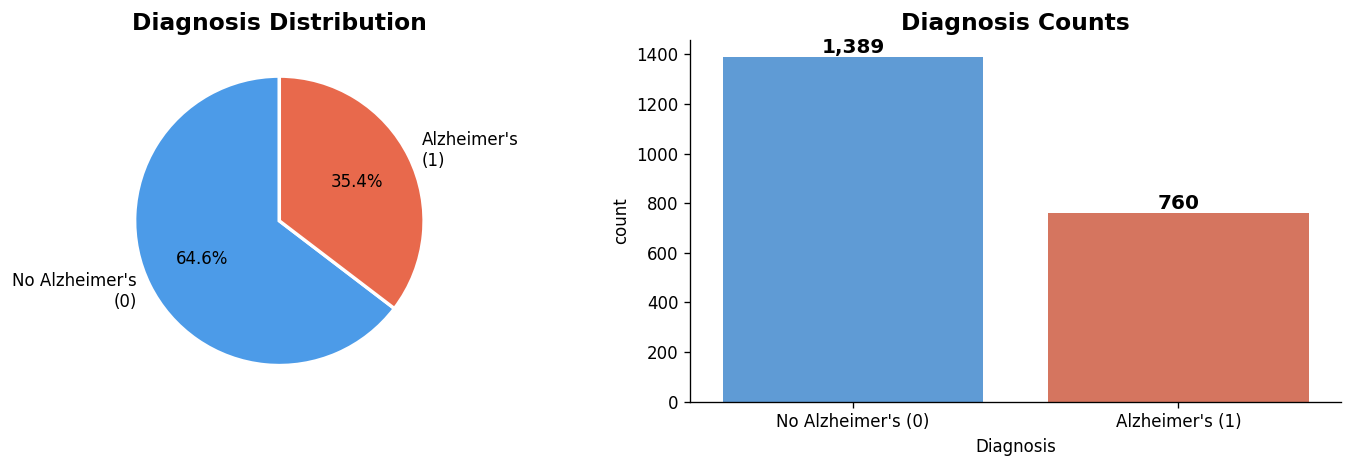

Class ratio  →  0 (No): 1,389  |  1 (Yes): 760


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
counts = data["Diagnosis"].value_counts()
axes[0].pie(counts, labels=["No Alzheimer's\n(0)", "Alzheimer's\n(1)"],
            autopct="%1.1f%%", colors=["#4C9BE8", "#E8694C"],
            startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[0].set_title("Diagnosis Distribution", fontsize=14, fontweight="bold")

# Count plot
sns.countplot(data=df, x="Diagnosis", palette=["#4C9BE8", "#E8694C"], ax=axes[1])
axes[1].set_xticklabels(["No Alzheimer's (0)", "Alzheimer's (1)"])
axes[1].set_title("Diagnosis Counts", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Diagnosis")
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Class ratio  →  0 (No): {counts[0]:,}  |  1 (Yes): {counts[1]:,}")


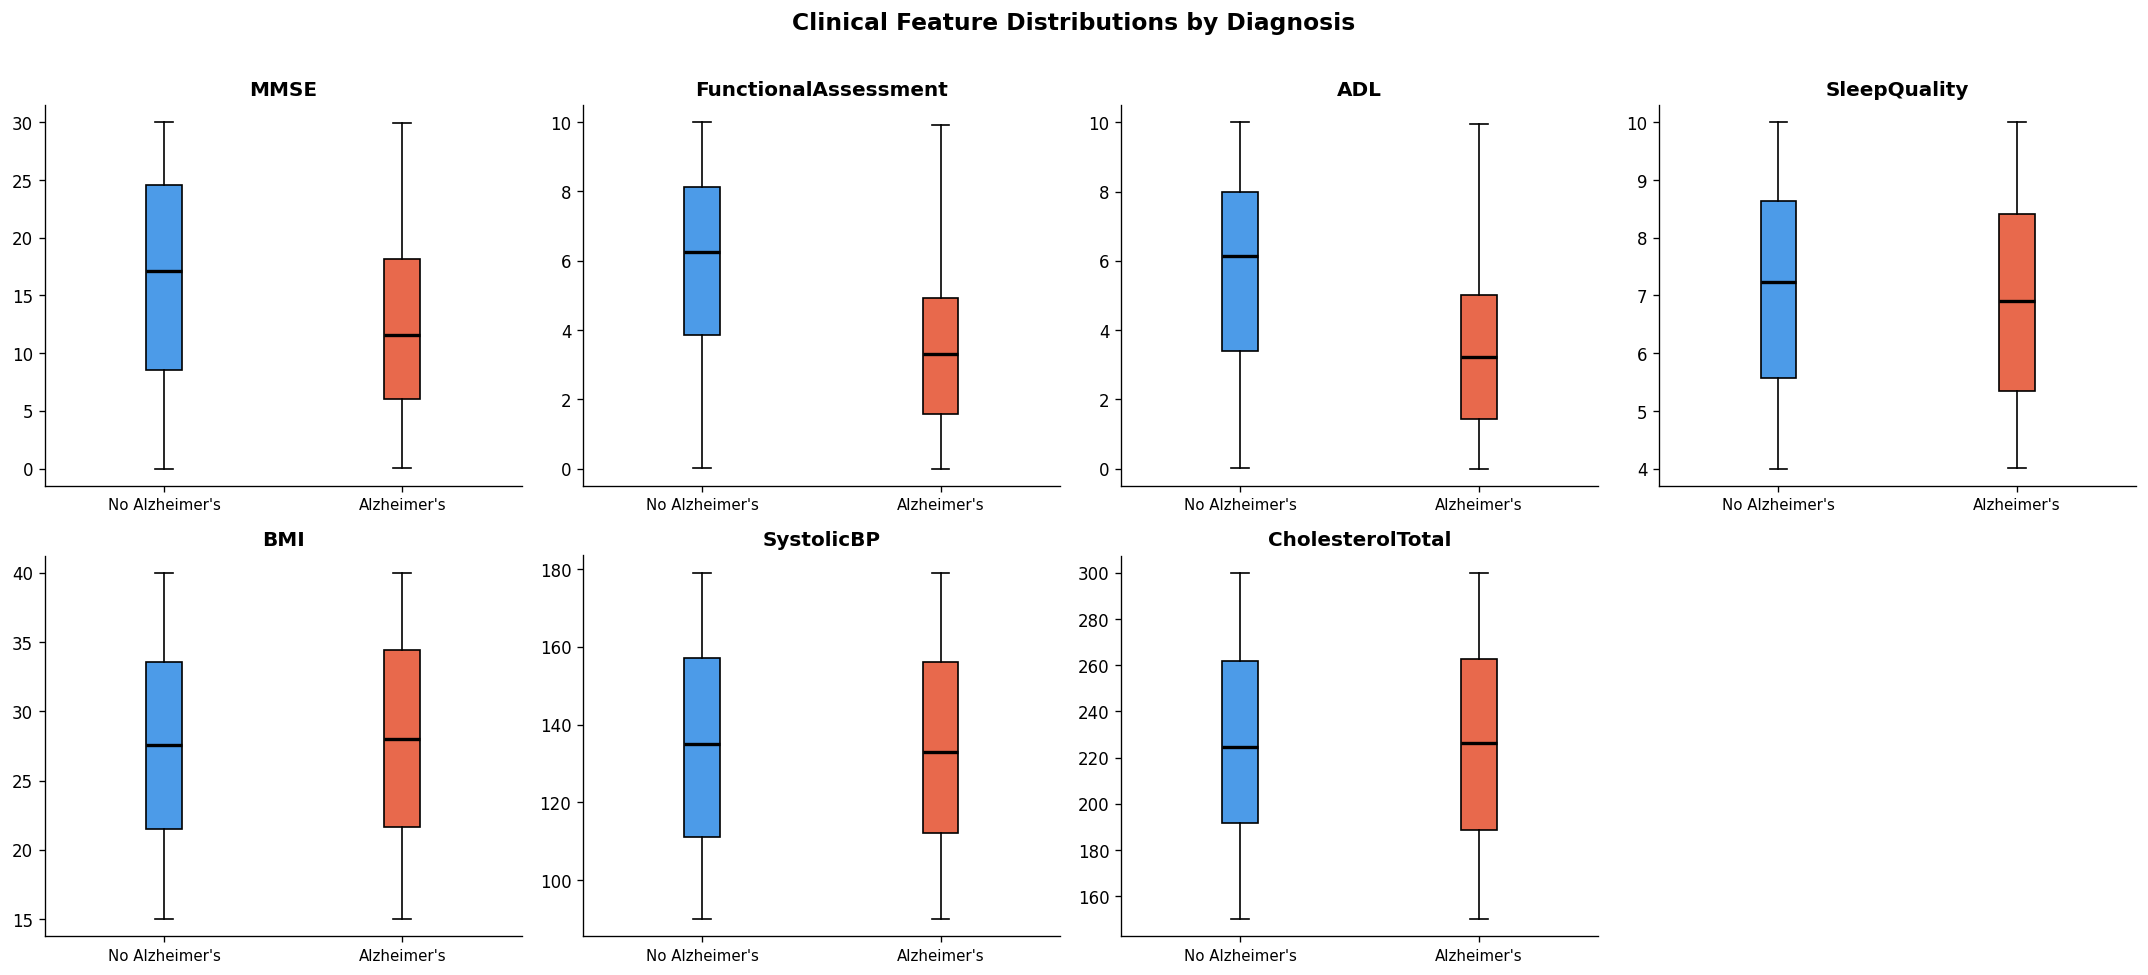

In [44]:
# Box plots for key continuous features split by diagnosis
continuous_features = ["MMSE", "FunctionalAssessment", "ADL",
                        "SleepQuality", "BMI", "SystolicBP", "CholesterolTotal"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(continuous_features):
    data_0 = data[data["Diagnosis"] == 0][feat]
    data_1 = data[data["Diagnosis"] == 1][feat]
    bp = axes[i].boxplot([data_0, data_1], patch_artist=True,
                          medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor("#4C9BE8")
    bp["boxes"][1].set_facecolor("#E8694C")
    axes[i].set_xticklabels(["No Alzheimer's", "Alzheimer's"])
    axes[i].set_title(feat, fontweight="bold")
    axes[i].tick_params(axis="x", labelsize=9)

axes[-1].axis("off")
plt.suptitle("Clinical Feature Distributions by Diagnosis", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("clinical_features.png", dpi=150, bbox_inches="tight")
plt.show()

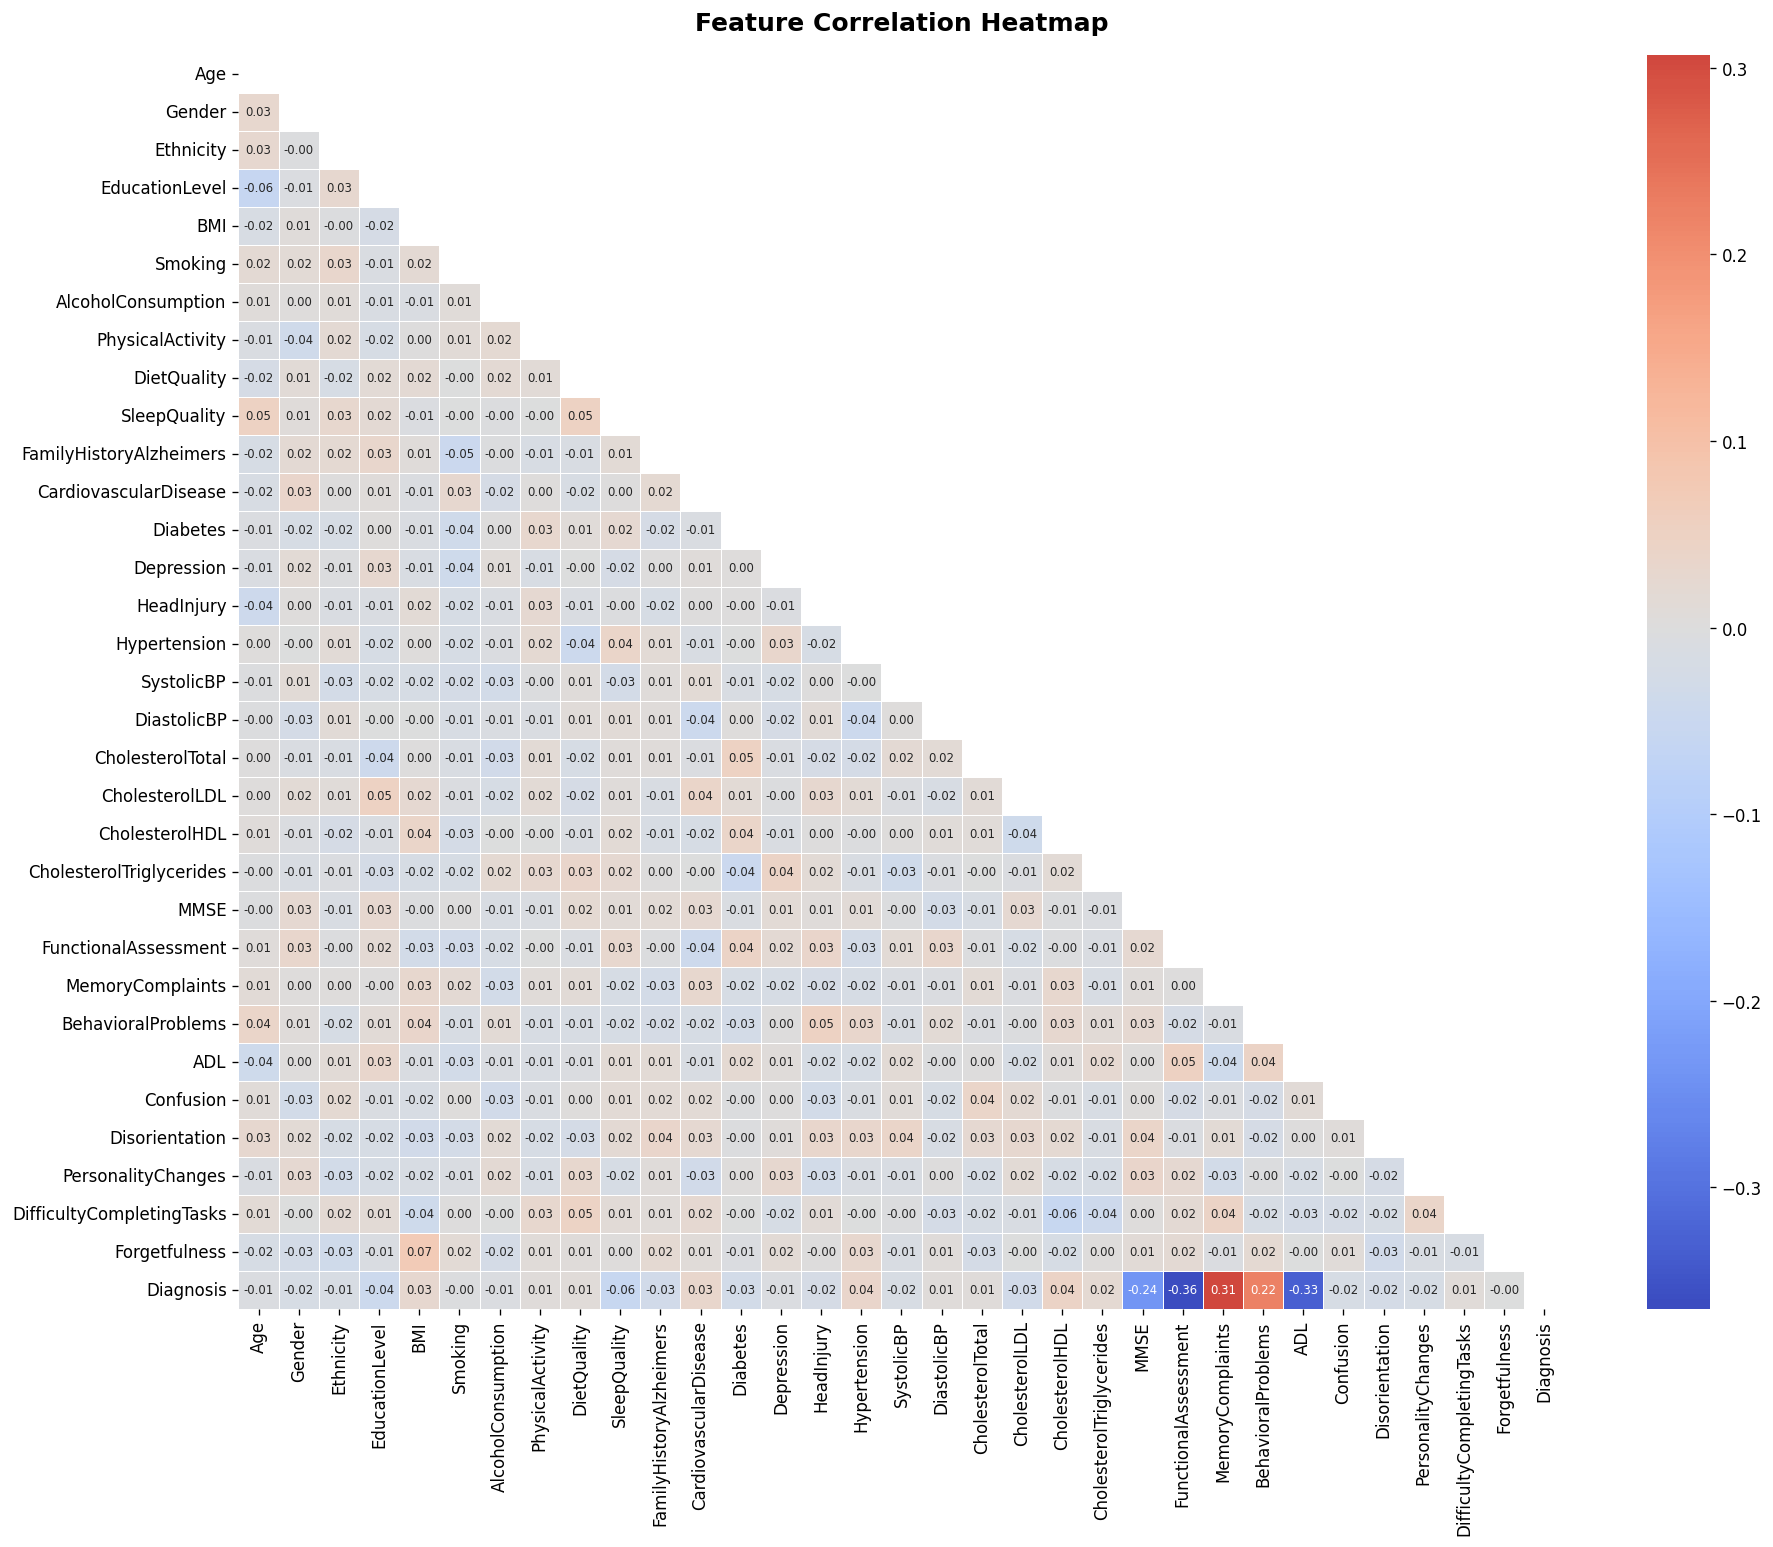

In [41]:
fig, ax = plt.subplots(figsize=(16, 13))
corr = data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", linewidths=0.4,
            cmap="coolwarm", center=0, ax=ax, annot_kws={"size": 7})
ax.set_title("Feature Correlation Heatmap", fontsize=15, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

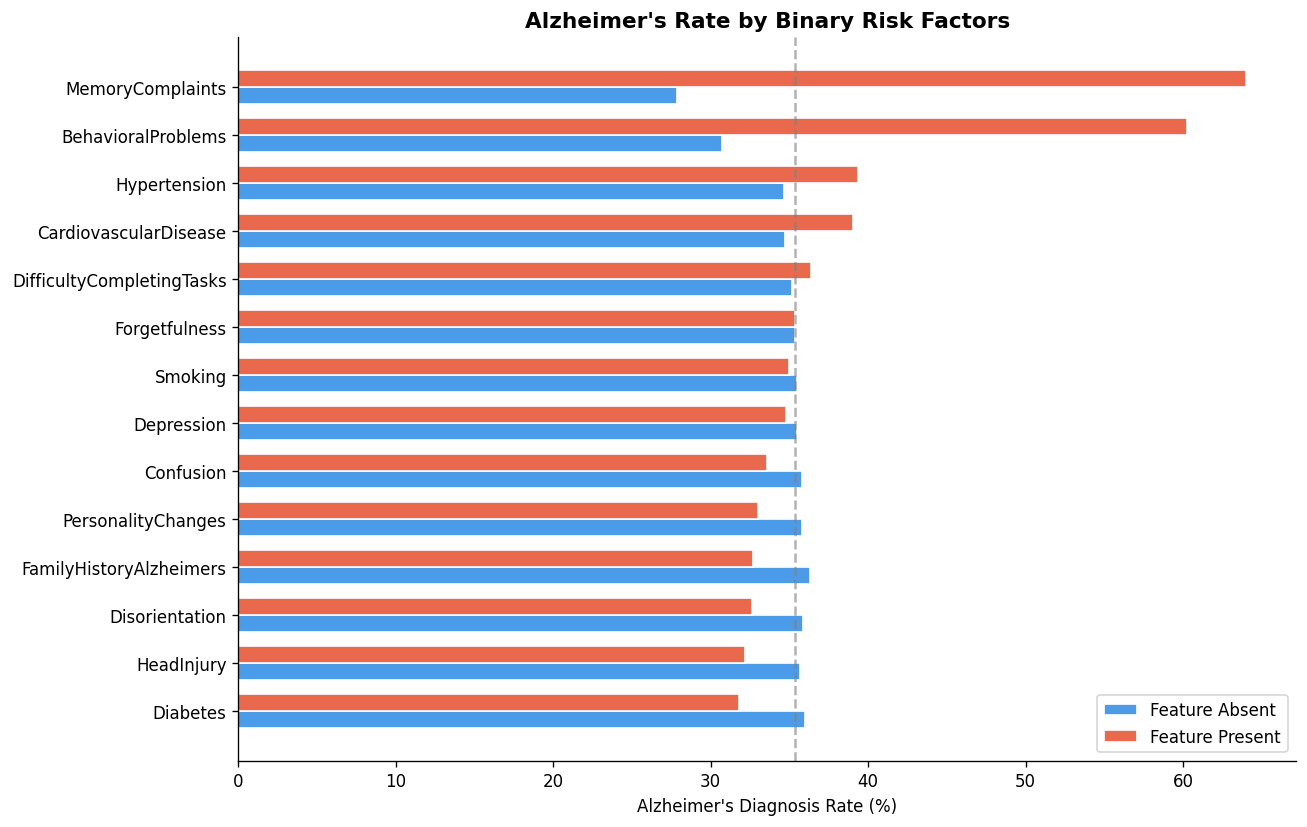

In [43]:
binary_features = [
    "Smoking", "FamilyHistoryAlzheimers", "CardiovascularDisease",
    "Diabetes", "Depression", "HeadInjury", "Hypertension",
    "MemoryComplaints", "BehavioralProblems", "Confusion",
    "Disorientation", "PersonalityChanges", "DifficultyCompletingTasks", "Forgetfulness"
]

# Calculate Alzheimer's rate for each binary feature
rates = {}
for feat in binary_features:
    rate_0 = data[data[feat] == 0]["Diagnosis"].mean() * 100
    rate_1 = data[data[feat] == 1]["Diagnosis"].mean() * 100
    rates[feat] = {"Without": rate_0, "With": rate_1}

rates_df = pd.DataFrame(rates).T.sort_values("With", ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
x = np.arange(len(rates_df))
width = 0.35
ax.barh(x - width/2, rates_df["Without"], width, label="Feature Absent", color="#4C9BE8", edgecolor="white")
ax.barh(x + width/2, rates_df["With"],    width, label="Feature Present", color="#E8694C", edgecolor="white")
ax.set_yticks(x)
ax.set_yticklabels(rates_df.index)
ax.set_xlabel("Alzheimer's Diagnosis Rate (%)")
ax.set_title("Alzheimer's Rate by Binary Risk Factors", fontweight="bold", fontsize=13)
ax.legend()
ax.axvline(data["Diagnosis"].mean() * 100, color="gray", linestyle="--", alpha=0.6, label="Overall rate")
plt.tight_layout()
plt.savefig("binary_feature_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 4: Prepare Data for Train/Test Split

In [23]:
X = data.drop(columns=['Diagnosis'])
y = data['Diagnosis']

print(f"Features: {X.shape[1]} columns.")
print(f"Target distribution:\n{y.value_counts()}")


Features: 32 columns.
Target distribution:
Diagnosis
0    1389
1     760
Name: count, dtype: int64


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")


Train size : 1719 samples
Test size  : 430 samples


### Step 5: Train XGBoost Model

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

#save the model to a json for use in /server for web application
model.save_model('../server/xgb_alzheimer.json')

### Step 6: Evaluation

In [26]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
print(f"Test Accuracy : {acc:.4f}")
print(f"Test ROC-AUC  : {auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Alzheimer's", "Alzheimer's"]))


Test Accuracy : 0.9488
Test ROC-AUC  : 0.9436

                precision    recall  f1-score   support

No Alzheimer's       0.95      0.97      0.96       278
   Alzheimer's       0.94      0.91      0.93       152

      accuracy                           0.95       430
     macro avg       0.95      0.94      0.94       430
  weighted avg       0.95      0.95      0.95       430



### Step 7: Evaluation Graphs

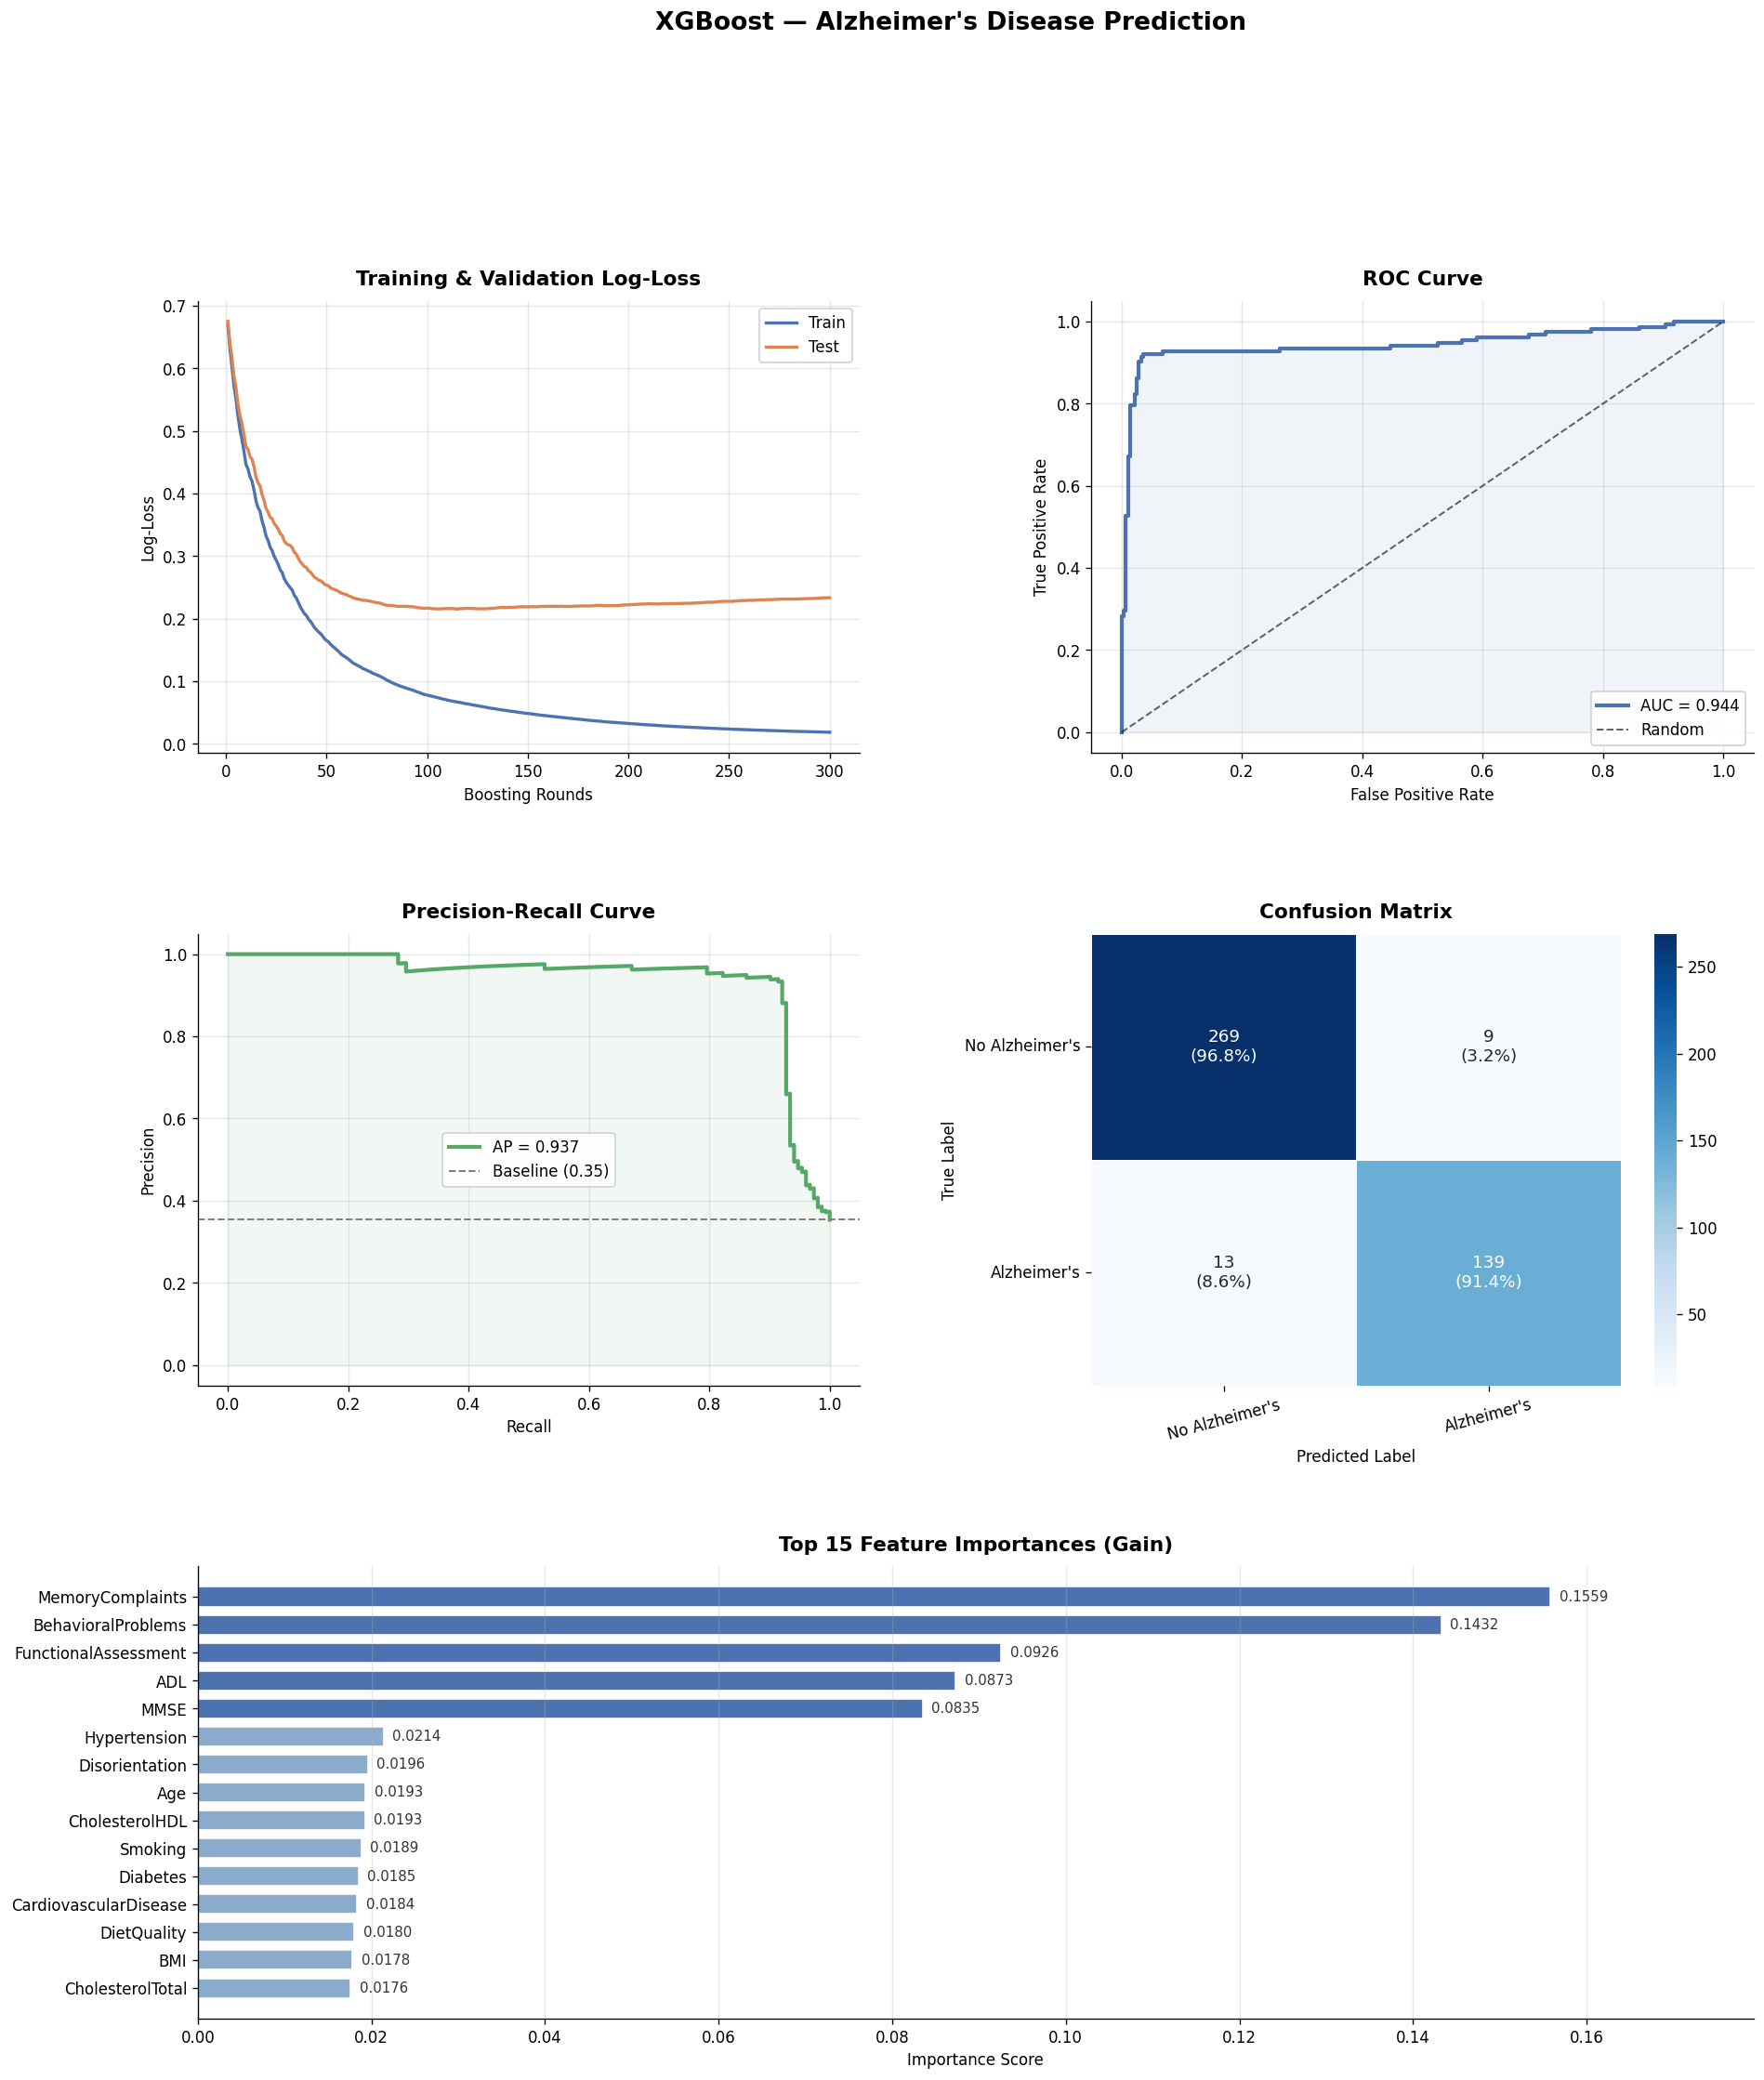

Evaluation graphs saved.


In [29]:
results = model.evals_result()
train_logloss = results['validation_0']['logloss']
test_logloss  = results['validation_1']['logloss']

fpr, tpr, _     = roc_curve(y_test, y_proba)
roc_auc         = roc_auc_score(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)
avg_precision   = average_precision_score(y_test, y_proba)
cm              = confusion_matrix(y_test, y_pred)

feat_imp = pd.Series(model.feature_importances_, index=X.columns) \
             .sort_values(ascending=False).head(15)

fig = plt.figure(figsize=(18, 20))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── 1. Training curve ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
epochs = range(1, len(train_logloss) + 1)
ax1.plot(epochs, train_logloss, color='#4C72B0', lw=2, label='Train')
ax1.plot(epochs, test_logloss,  color='#DD8452', lw=2, label='Test')
ax1.set_title('Training & Validation Log-Loss', fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel('Boosting Rounds')
ax1.set_ylabel('Log-Loss')
ax1.legend(framealpha=0.9)
ax1.grid(alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

# ── 2. ROC curve ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(fpr, tpr, color='#4C72B0', lw=2.5, label=f'AUC = {roc_auc:.3f}')
ax2.plot([0,1], [0,1], 'k--', lw=1.2, alpha=0.6, label='Random')
ax2.fill_between(fpr, tpr, alpha=0.08, color='#4C72B0')
ax2.set_title('ROC Curve', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend(loc='lower right', framealpha=0.9)
ax2.grid(alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

# ── 3. Precision-Recall curve ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(recall, precision, color='#55A868', lw=2.5, label=f'AP = {avg_precision:.3f}')
ax3.fill_between(recall, precision, alpha=0.08, color='#55A868')
baseline = y_test.mean()
ax3.axhline(baseline, color='gray', lw=1.2, linestyle='--', label=f'Baseline ({baseline:.2f})')
ax3.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold', pad=10)
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.legend(framealpha=0.9)
ax3.grid(alpha=0.3)
ax3.spines[['top','right']].set_visible(False)

# ── 4. Confusion matrix ────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
labels  = ["No Alzheimer's", "Alzheimer's"]
cm_pct  = cm.astype(float) / cm.sum(axis=1, keepdims=True)
annots  = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1%})" for j in range(2)] for i in range(2)])
sns.heatmap(cm, annot=annots, fmt='', cmap='Blues', ax=ax4,
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, linecolor='white', cbar=True,
            annot_kws={'fontsize': 11})
ax4.set_title('Confusion Matrix', fontsize=13, fontweight='bold', pad=10)
ax4.set_xlabel('Predicted Label')
ax4.set_ylabel('True Label')
ax4.tick_params(axis='x', rotation=15)
ax4.tick_params(axis='y', rotation=0)

# ── 5. Feature importances ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :])
colors = ['#4C72B0' if i < 5 else '#8AABCC' for i in range(len(feat_imp))]
bars = ax5.barh(feat_imp.index[::-1], feat_imp.values[::-1], color=colors[::-1],
                edgecolor='white', height=0.7)
for bar, val in zip(bars, feat_imp.values[::-1]):
    ax5.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', ha='left', fontsize=9, color='#333')
ax5.set_title('Top 15 Feature Importances (Gain)', fontsize=13, fontweight='bold', pad=10)
ax5.set_xlabel('Importance Score')
ax5.grid(axis='x', alpha=0.3)
ax5.spines[['top','right']].set_visible(False)
ax5.set_xlim(0, feat_imp.max() * 1.15)

fig.suptitle("XGBoost — Alzheimer's Disease Prediction", fontsize=16, fontweight='bold', y=1.01)
plt.savefig('evaluation_graphs.png', bbox_inches='tight', dpi=150)
plt.show()
print("Evaluation graphs saved.")


### Step 8: Cross-Validation Summary

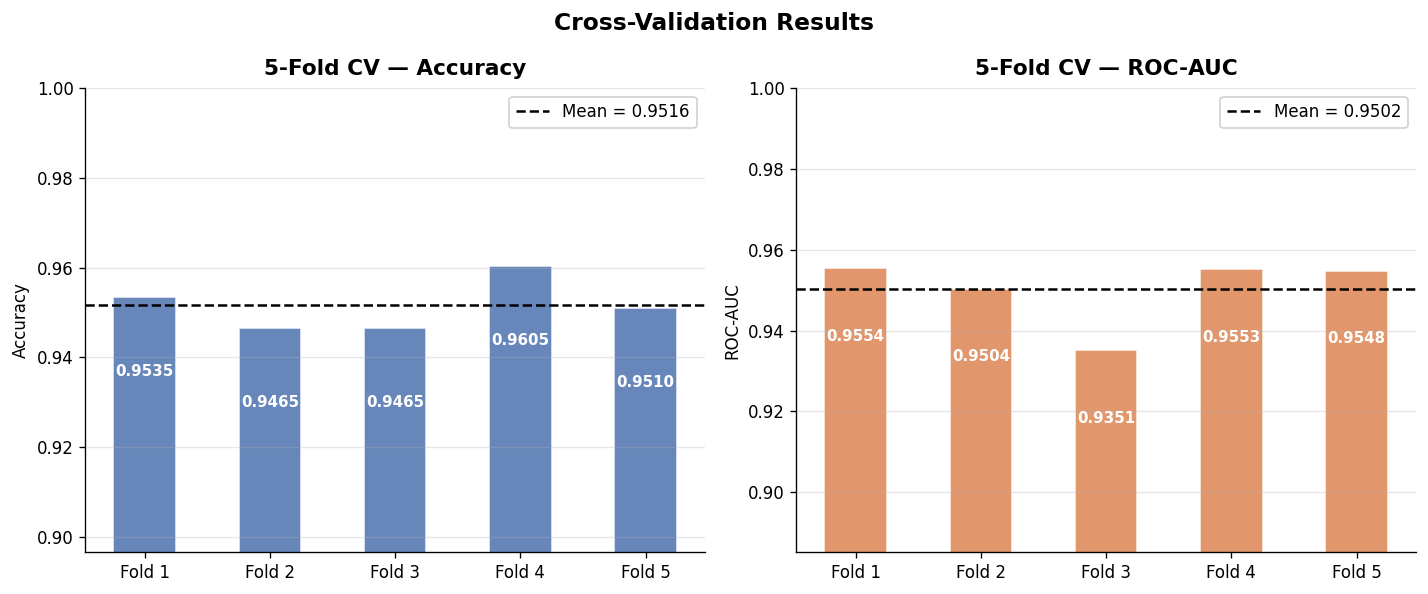

CV Accuracy : 0.9516 ± 0.0052
CV ROC-AUC  : 0.9502 ± 0.0078


In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, n_jobs=-1
)

acc_scores = cross_val_score(cv_model, X, y, cv=cv, scoring='accuracy')
auc_scores = cross_val_score(cv_model, X, y, cv=cv, scoring='roc_auc')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, scores, metric, color in zip(
        axes, [acc_scores, auc_scores],
        ['Accuracy', 'ROC-AUC'], ['#4C72B0', '#DD8452']):
    folds = [f'Fold {i+1}' for i in range(len(scores))]
    bars = ax.bar(folds, scores, color=color, alpha=0.85, edgecolor='white', width=0.5)
    ax.axhline(scores.mean(), color='black', lw=1.5, linestyle='--',
               label=f'Mean = {scores.mean():.4f}')
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, val - 0.015,
                f'{val:.4f}', ha='center', va='top', fontsize=9, color='white', fontweight='bold')
    ax.set_title(f'5-Fold CV — {metric}', fontsize=13, fontweight='bold', pad=8)
    ax.set_ylabel(metric)
    ax.set_ylim(max(0, scores.min() - 0.05), min(1, scores.max() + 0.05))
    ax.legend(framealpha=0.9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Cross-Validation Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cv_results.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"CV Accuracy : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
print(f"CV ROC-AUC  : {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")


### Step 9: Function Creation & Simplification

In [ ]:
def loadDataset():
    data = pd.read_csv('../datasets/alzheimers_disease_data.csv')
    drop_cols = ['PatientID', 'DoctorInCharge']
    data.drop(columns=drop_cols, inplace=True)
    return data

def predictAlzheimer(input_data):
    model = XGBClassifier()
    model.load_model('../server/xgb_alzheimer.json')
    input_df = pd.DataFrame([input_data])
    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]
    return {"prediction": int(prediction), "probability": float(probability)}